# Olist Revenue Leakage - Exploratory Data Analysis
This notebook performs Exploratory Data Analysis (EDA) to understand the revenue leakage patterns, check missing values, analyze order status, inspect freight burden ratios, and plot key metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

import sys
import os
sys.path.append(os.path.abspath("../python"))
from etl import build_fact_table
from transform import engineer_leakage_features

# Build fact table and engineer features using the raw files relative to this folder
df = build_fact_table("../data")
df = engineer_leakage_features(df)
print("Dataframe loaded successfully. Shape:", df.shape)
df.head()

Dataframe loaded successfully. Shape: (99441, 35)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,n_items,total_price,...,is_cancelled,is_late,delay_days,is_low_review,freight_ratio,is_high_freight_burden,is_payment_issue,leakage_amount,leakage_reason,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,29.99,...,False,False,0,False,0.290764,False,False,0.00,None,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,118.70,...,False,False,0,False,0.191744,False,False,0.00,None,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,159.90,...,False,False,0,False,0.120200,False,False,0.00,None,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,45.00,...,False,False,0,False,0.604444,True,False,13.70,High Freight Burden,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,19.90,...,False,False,0,False,0.438191,True,False,2.75,High Freight Burden,2018-02


## Missing Values Overview

C:\Users\HP\AppData\Local\Temp\ipykernel_20008\1372437020.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")


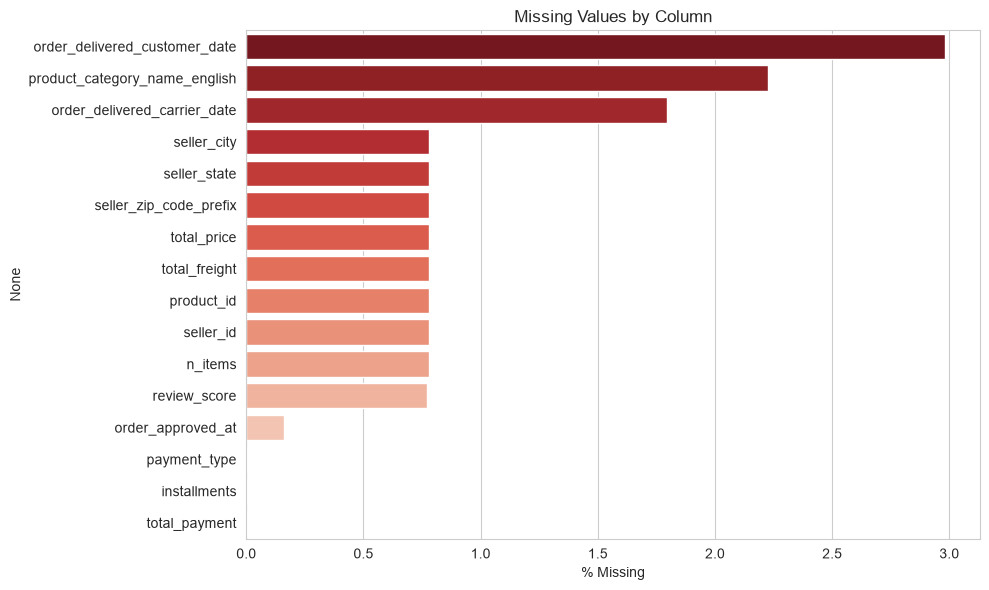

In [2]:
missing = df.isna().sum().sort_values(ascending=False)
missing = (missing[missing > 0] / len(df)) * 100

if len(missing) > 0:
    plt.figure(figsize=(10,6))
    sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")
    plt.xlabel("% Missing")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

## Order Status Distribution

C:\Users\HP\AppData\Local\Temp\ipykernel_20008\1757282576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order_status_counts.values, y=order_status_counts.index, palette="viridis")


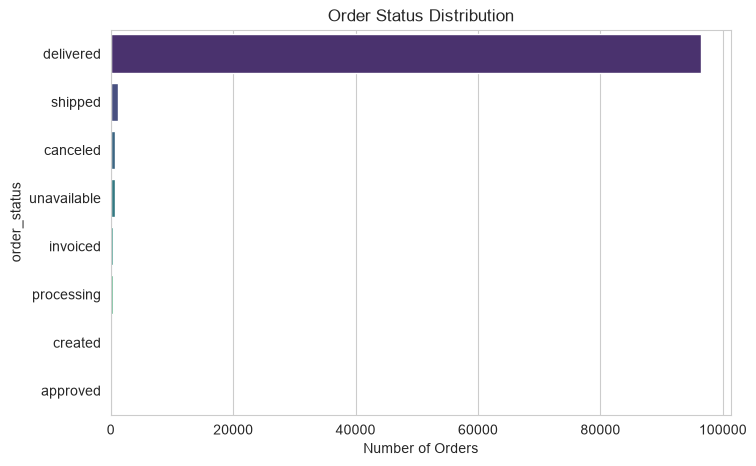

In [3]:
plt.figure(figsize=(8,5))
order_status_counts = df["order_status"].value_counts()
sns.barplot(x=order_status_counts.values, y=order_status_counts.index, palette="viridis")
plt.title("Order Status Distribution")
plt.xlabel("Number of Orders")
plt.show()

## Revenue vs Leakage Overview

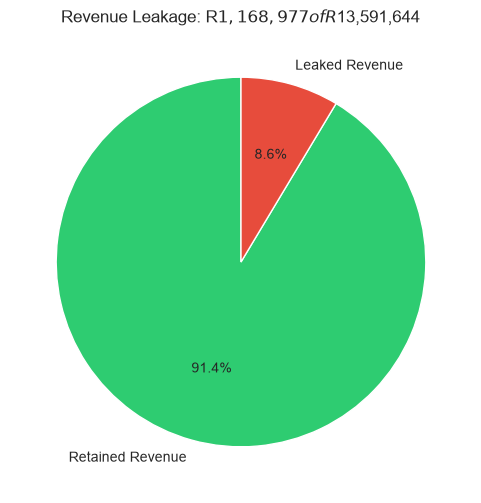

In [4]:
total_revenue = df["total_price"].sum()
total_leakage = df["leakage_amount"].sum()

fig, ax = plt.subplots(figsize=(6,6))
ax.pie([total_revenue - total_leakage, total_leakage],
       labels=["Retained Revenue", "Leaked Revenue"],
       autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90)
ax.set_title(f"Revenue Leakage: R${total_leakage:,.0f} of R${total_revenue:,.0f}")
plt.show()

## Leakage by Root Cause

C:\Users\HP\AppData\Local\Temp\ipykernel_20008\728585961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_df.values, y=reason_df.index, palette="mako")


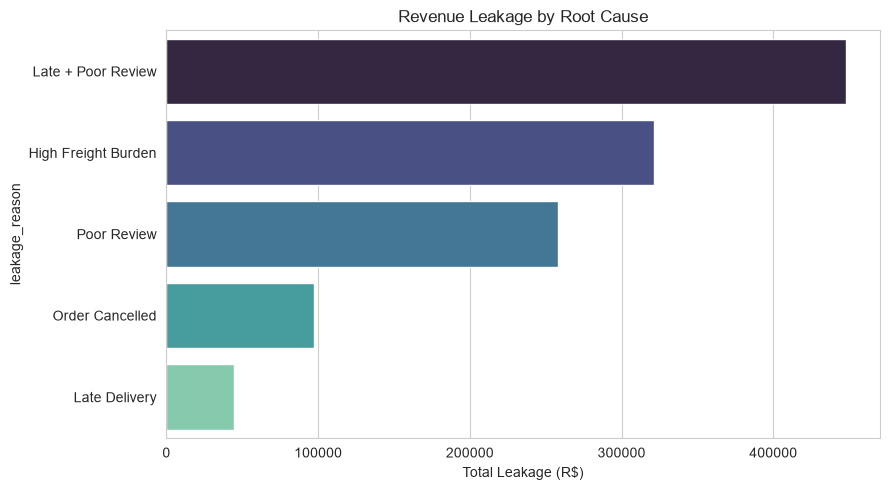

In [5]:
reason_df = df[df.leakage_reason != "None"].groupby("leakage_reason")["leakage_amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=reason_df.values, y=reason_df.index, palette="mako")
plt.xlabel("Total Leakage (R$)")
plt.title("Revenue Leakage by Root Cause")
plt.tight_layout()
plt.show()

## Monthly Leakage Trend

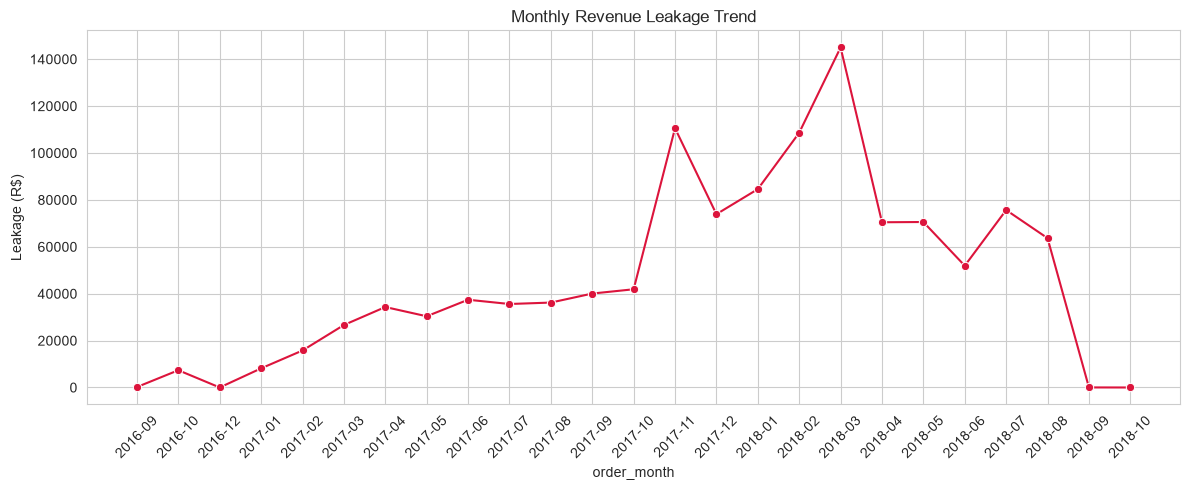

In [6]:
monthly = df.groupby("order_month")["leakage_amount"].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x="order_month", y="leakage_amount", marker="o", color="crimson")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Leakage Trend")
plt.ylabel("Leakage (R$)")
plt.tight_layout()
plt.show()

## Freight Ratio Distribution

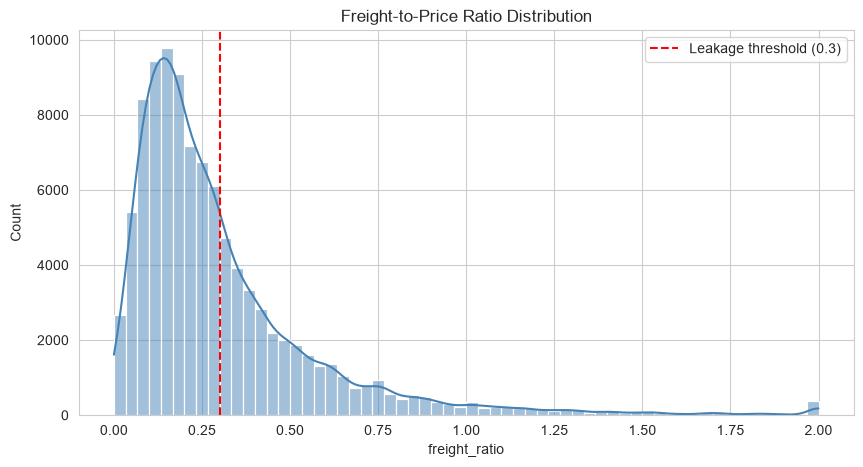

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df["freight_ratio"].clip(upper=2), bins=60, kde=True, color="steelblue")
plt.axvline(0.3, color="red", linestyle="--", label="Leakage threshold (0.3)")
plt.title("Freight-to-Price Ratio Distribution")
plt.legend()
plt.show()

## Review Score vs Leakage

C:\Users\HP\AppData\Local\Temp\ipykernel_20008\3451537876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="review_score", y="leakage_amount", palette="coolwarm")


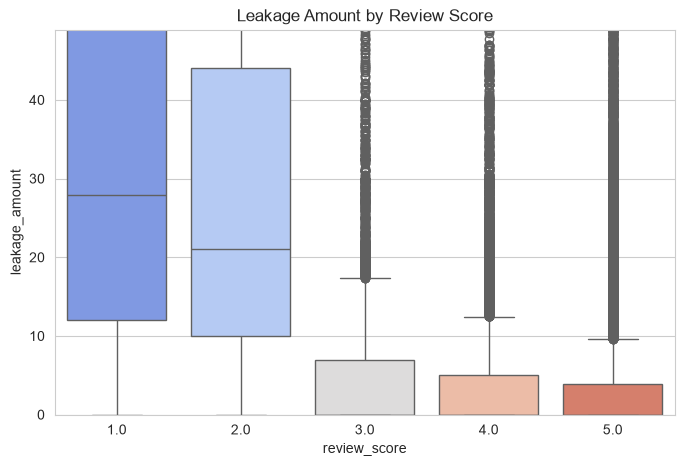

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="review_score", y="leakage_amount", palette="coolwarm")
plt.ylim(0, df["leakage_amount"].quantile(0.95))
plt.title("Leakage Amount by Review Score")
plt.show()

## Delay Days vs Leakage

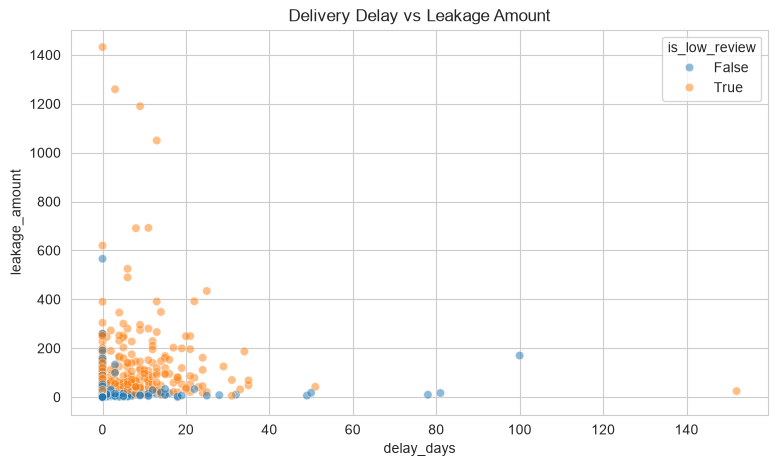

In [9]:
plt.figure(figsize=(9,5))
sample = df.sample(min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample, x="delay_days", y="leakage_amount", hue="is_low_review", alpha=0.5)
plt.title("Delivery Delay vs Leakage Amount")
plt.show()

## Top Categories & Sellers

C:\Users\HP\AppData\Local\Temp\ipykernel_20008\2478166795.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_leak.values, y=cat_leak.index, ax=axes[0], palette="rocket")
C:\Users\HP\AppData\Local\Temp\ipykernel_20008\2478166795.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seller_leak.values, y=seller_leak.index, ax=axes[1], palette="flare")


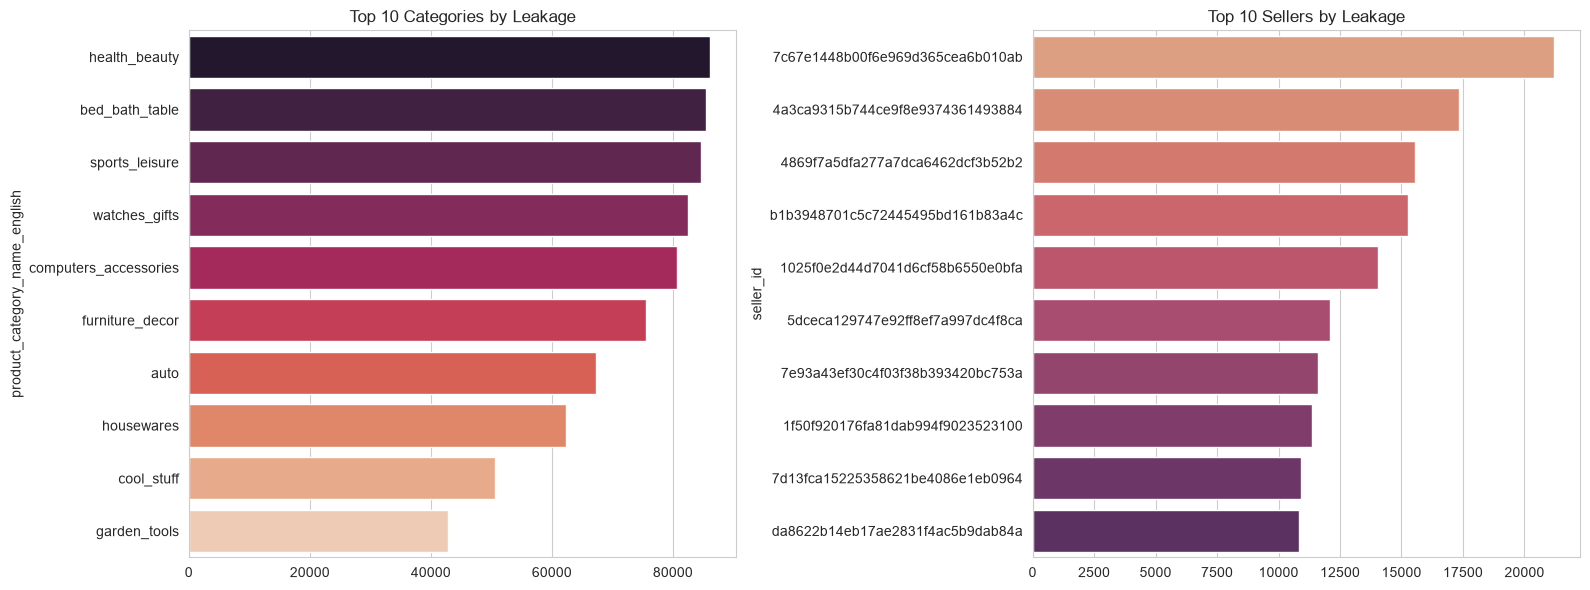

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

cat_leak = df.groupby("product_category_name_english")["leakage_amount"].sum().nlargest(10)
sns.barplot(x=cat_leak.values, y=cat_leak.index, ax=axes[0], palette="rocket")
axes[0].set_title("Top 10 Categories by Leakage")

seller_leak = df.groupby("seller_id")["leakage_amount"].sum().nlargest(10)
sns.barplot(x=seller_leak.values, y=seller_leak.index, ax=axes[1], palette="flare")
axes[1].set_title("Top 10 Sellers by Leakage")

plt.tight_layout()
plt.show()

## Correlation Heatmap & Export

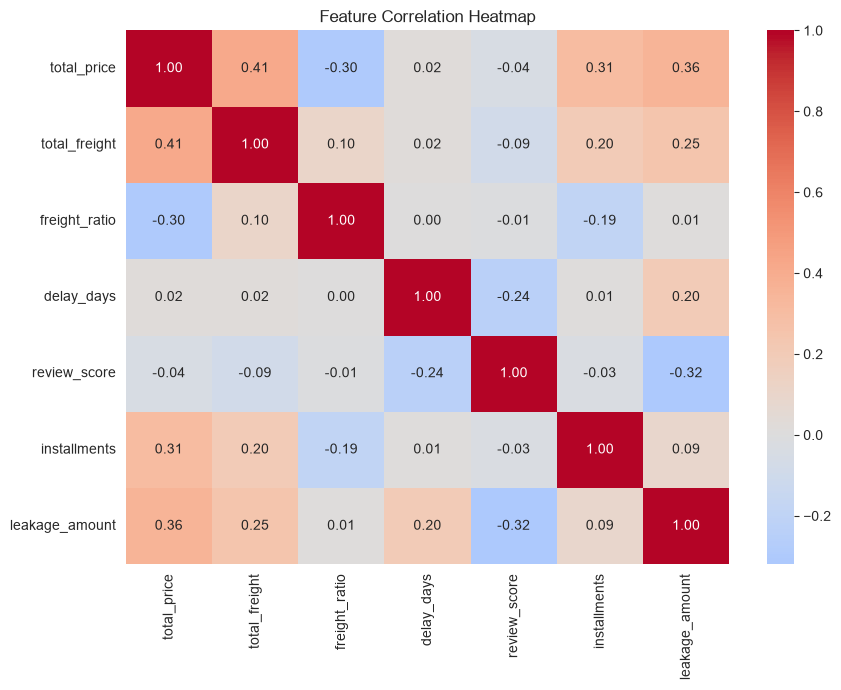

Cleaned and engineered fact table exported to data/processed_fact_orders.csv


In [11]:
numeric_cols = ["total_price", "total_freight", "freight_ratio", "delay_days",
                 "review_score", "installments", "leakage_amount"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Export data
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/processed_fact_orders.csv", index=False)
print("Cleaned and engineered fact table exported to data/processed_fact_orders.csv")